# Redes convolucionales para clasificación de señales bursátiles

Clasificación de señales Buy, Hold y Sell a partir de imágenes generadas con ventanas de precios de la acción de Loews Corporation.


In [ ]:
from pathlib import Path
import zipfile

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
DATA_DIR = PROJECT_ROOT / "data"
ARCHIVE_PATH = DATA_DIR / "LoewsCorporation.zip"
IMAGE_DIR = DATA_DIR / "LoewsCorporation"

if not IMAGE_DIR.exists():
    if not ARCHIVE_PATH.exists():
        parts = sorted(DATA_DIR.glob("LoewsCorporation.zip.part*"))
        if not parts:
            raise FileNotFoundError("No se encontraron las partes del archivo LoewsCorporation.zip en data/.")
        with open(ARCHIVE_PATH, "wb") as target:
            for part in parts:
                target.write(part.read_bytes())
    with zipfile.ZipFile(ARCHIVE_PATH) as zf:
        zf.extractall(DATA_DIR)

image_directory = str(IMAGE_DIR)


# LIBRERIAS

In [ ]:
!pip install mplfinance
! pip install pandas_ta


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.0/75.0 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.1/115.1 kB 8.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pandas_ta: filename=pandas_ta-0.3.14b0-py3-none-any.whl size=218909 sha256=03a3fd1acad44fb71c337847ba529c7b945f104b2ac6bde8b8f4c63c3e28116c
  Stored in directory: /root/.cache/pip/wheels/69/00/ac/f7fa862c34b0e2ef320175100c233377b4c558944f12474cf0
Successfully built pandas_ta


In [ ]:
import pandas as pd
import pandas_ta as ta
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import mplfinance as mpf
import yfinance as yf
import matplotlib.pyplot as plt
import os

from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler



# DATOS

In [ ]:
# Datos de acciones de LoewsCorporation
LoewsCorporation = yf.Ticker("L")
df = LoewsCorporation.history(period="max", interval="1d") # Ajuste el período


In [ ]:
df.head()


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1980-03-17 00:00:00-05:00,0.0,0.491787,0.483790,0.483790,1044000,0.0,0.0
1980-03-18 00:00:00-05:00,0.0,0.484790,0.472795,0.484790,855000,0.0,0.0
1980-03-19 00:00:00-05:00,0.0,0.497785,0.488789,0.495786,1872000,0.0,0.0
1980-03-20 00:00:00-05:00,0.0,0.497785,0.492786,0.493786,720000,0.0,0.0
1980-03-21 00:00:00-05:00,0.0,0.493786,0.487789,0.489788,1170000,0.0,0.0


In [ ]:
df.shape


(11257, 7)

In [ ]:
print(df.index.min())
print(df.index.max())


1980-03-17 00:00:00-05:00
2024-11-07 00:00:00-05:00


In [ ]:
df.describe()


,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,11257.000000,11257.000000,11257.000000,11257.000000,1.125700e+04,11257.000000,11257.000000
mean,22.894971,23.409075,22.996035,23.204232,1.556007e+06,0.000653,0.001110
std,20.049700,19.867672,19.557076,19.710517,1.728553e+06,0.005910,0.053515
min,0.000000,0.447806,0.422817,0.428814,0.000000e+00,0.000000,0.000000
25%,6.185520,6.229681,6.144169,6.184644,7.967000e+05,0.000000,0.000000
50%,14.681013,14.843160,14.461309,14.672527,1.205400e+06,0.000000,0.000000
75%,39.399059,39.659728,39.060959,39.352291,1.881000e+06,0.000000,0.000000
max,82.809998,83.473299,81.959999,82.760002,1.151190e+08,0.063000,3.000000


# GRÁFICOS

In [ ]:
df.index = pd.to_datetime(df.index)
df1 = df[df.index >= '2024-09-01'] # Se filtran los meses


In [ ]:
df1.shape


(48, 7)

In [ ]:
mpf.plot(
    df,
    type='candle',
    style=mpf.make_mpf_style(gridstyle=''),
    title='',
    ylabel='',
    volume=True,
    ylabel_lower='',
    show_nontrading=True,
    savefig='LC.png'
)



/usr/local/lib/python3.10/dist-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


In [ ]:
mpf.plot(
    df1,
    type='candle',
    style=mpf.make_mpf_style(gridstyle=''),
    title='',
    ylabel='',
    volume=True,
    ylabel_lower='',
    show_nontrading=True,
    savefig='LC.png'
)


(800, 575)


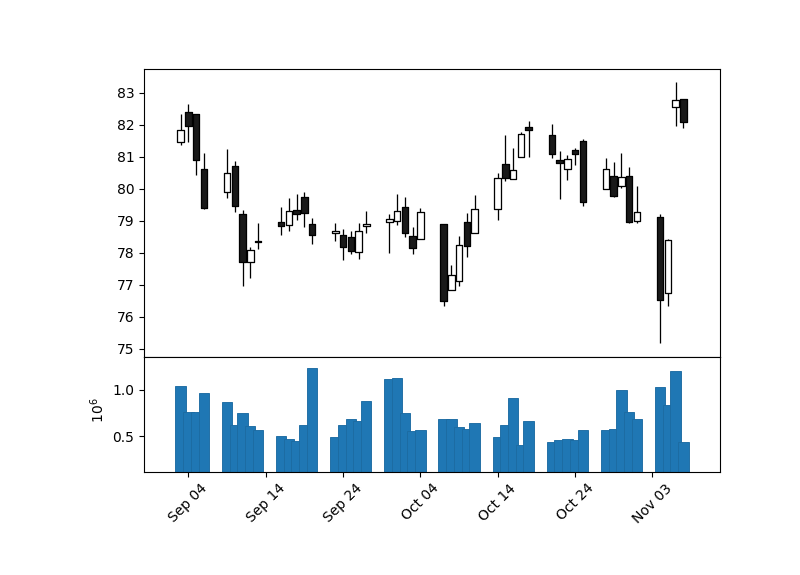

In [ ]:
from PIL import Image, ImageFilter

im = Image.open('LC.png')
print(im.size)
display(im)


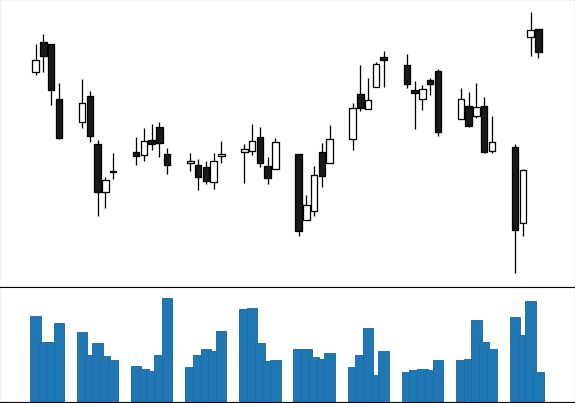

In [ ]:
# recorte
left = 145
top = 70
right = 720
bottom = 473
im2 = im.crop((left, top, right, bottom))
display(im2)


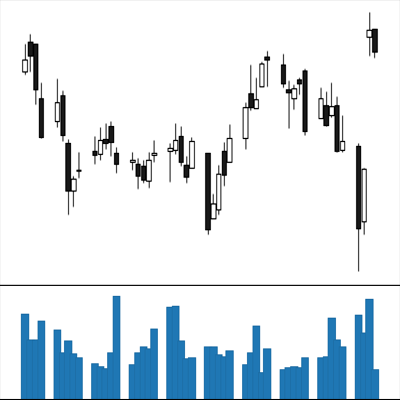

In [ ]:
# cambio de tamaño
newsize = (400, 400)
im3 = im2.resize(newsize)
display(im3)


In [ ]:
im3.save('LC1.png')


In [ ]:
df1.ta.bbands(close='Close', append=True)
df1.head()


<ipython-input-16-0890731c3780>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.ta.bbands(close='Close', append=True)
<ipython-input-16-0890731c3780>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.ta.bbands(close='Close', append=True)
<ipython-input-16-0890731c3780>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable

,Open,High,Low,Close,Volume,Dividends,Stock Splits,BBL_5_2.0,BBM_5_2.0,BBU_5_2.0,BBB_5_2.0,BBP_5_2.0
Date,,,,,,,,,,,,
2024-09-03 00:00:00-04:00,81.459999,82.339996,81.360001,81.820000,1041800,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2024-09-04 00:00:00-04:00,82.379997,82.629997,81.470001,81.959999,761000,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2024-09-05 00:00:00-04:00,82.330002,82.330002,80.430000,80.900002,762600,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2024-09-06 00:00:00-04:00,80.620003,81.099998,79.349998,79.389999,965800,0.0,0.0,NaN,NaN,NaN,NaN,NaN
2024-09-09 00:00:00-04:00,79.879997,81.250000,79.699997,80.480003,868200,0.0,0.0,79.0283,80.910001,82.791701,4.651342,0.385742


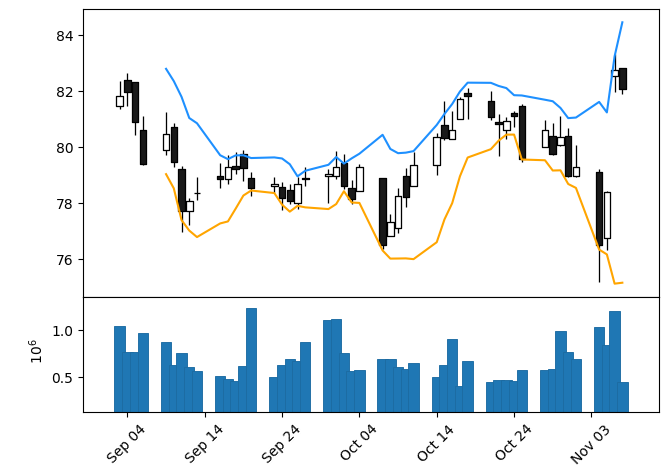

In [ ]:
bbl = mpf.make_addplot(df1["BBL_5_2.0"], color="orange", width=1.5)
bbu = mpf.make_addplot(df1["BBU_5_2.0"], color="dodgerblue", width=1.5)

mpf.plot(
    df1,
    type='candle',
    addplot = [bbl, bbu],
    style=mpf.make_mpf_style(gridstyle=''),
    title='',
    ylabel='',
    volume=True,
    ylabel_lower='',
    show_nontrading=True,
    #savefig='LC.png'
)


# REDES CONVOLUCIONALES

## Imágenes y Etiquetas

In [ ]:
df2 = df[df.index >= '2000-01-01'] # Se toman los datos desde el año 2000 hasta la actualidad
df2.shape


(6254, 7)

In [ ]:
# IMÁGENES Y ETIQUETAS

WINDOW_SIZE = 7  # Días de entrada para crear la imagen
THRESHOLD = 0.02  # 2% de cambio para etiquetar como compra o venta
df = df2[['Close']]  # Solo utilizaremos el valor de cierre

# Normalizamos los datos de cierre
scaler = MinMaxScaler(feature_range=(0, 1))
df['Close'] = scaler.fit_transform(df['Close'].values.reshape(-1, 1))

# Definimos las carpetas de salida dentro del repositorio
output_dirs = {
    "buy": str(IMAGE_DIR / "Buy"),
    "sell": str(IMAGE_DIR / "Sell"),
    "hold": str(IMAGE_DIR / "Hold")
}

# Función para calcular el cambio porcentual entre el promedio de los primeros 7 días y el 8º día
def get_label(serie):
    avg_7_days = serie[:WINDOW_SIZE].mean()  # Promedio de los primeros 7 días
    change = (serie[-1] - avg_7_days) / avg_7_days  # Cambio porcentual con respecto al promedio de 7 días
    if change > THRESHOLD:
        return "buy"
    elif change < -THRESHOLD:
        return "sell"
    else:
        return "hold"

# Generamos imágenes con ventanas móviles
image_count = {"buy": 0, "sell": 0, "hold": 0}
for i in range(len(df) - WINDOW_SIZE):
    window_data = df['Close'].iloc[i:i + WINDOW_SIZE + 1]  # 7 días + 8º día
    label = get_label(window_data.values)  # Obtenemos la etiqueta basada en el cambio porcentual respecto al promedio

    # Graficamos los primeros 7 días
    plt.figure(figsize=(4, 4))
    plt.plot(window_data[:WINDOW_SIZE].values, color='blue')
    plt.title(f"Label: {label}")
    plt.axis('off')  # Quitamos los ejes para centrarnos en la serie
    plt.tight_layout()

    # Guardamos la imagen en la carpeta correspondiente
    image_path = os.path.join(output_dirs[label], f"stock_day_{i}_label_{label}.png")
    plt.savefig(image_path, bbox_inches='tight', pad_inches=0)
    plt.close()

    # Contamos las imágenes por etiqueta
    image_count[label] += 1

# Mostramos cuántas imágenes se han guardado por etiqueta
for label, count in image_count.items():
    print(f"Imágenes guardadas en la etiqueta '{label}': {count}")


<ipython-input-51-e0f4b02a0ffd>:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Close'] = scaler.fit_transform(df['Close'].values.reshape(-1, 1))


Imágenes guardadas en la etiqueta 'buy': 1431
Imágenes guardadas en la etiqueta 'sell': 1148
Imágenes guardadas en la etiqueta 'hold': 3667


## Train / Test

In [ ]:
# Tamaño del batch y ruta del conjunto de imágenes
batch_size = 128
image_directory = str(IMAGE_DIR)

# Generador de datos con aumentos de zoom y flip horizontal
train_datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    zoom_range=[0.8, 1.2],
    horizontal_flip=True
)

# Generador para cargar las imágenes desde el directorio, ajustado al tamaño de entrada del modelo
train_generator = train_datagen.flow_from_directory(
    directory=image_directory,     # Ruta a las imágenes de acciones
    target_size=(100, 100),        # Dimensión a la que redimensionamos las imágenes
    batch_size=batch_size,
    classes=['Buy', 'Hold', 'Sell'],  # Etiquetas de las carpetas
    class_mode='categorical'       # Asumimos clasificación multiclase (compra, venta, o mantener)
)


Found 6246 images belonging to 3 classes.


## Modelo 1

In [ ]:
# Definimos el modelo
model = tf.keras.models.Sequential([
    # Entrada
    tf.keras.layers.Input(shape=(100, 100, 3)),  # Entrada en color RGB (3 canales)

    # Convolución 1
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Convolución 2
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Convolución 3
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Convolución 4
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Convolución 5
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Achatamiento
    tf.keras.layers.Flatten(),

    # Capa densa
    tf.keras.layers.Dense(100, activation='relu'),

    # Capa de salida con 3 neuronas (una para cada clase)
    tf.keras.layers.Dense(3, activation='softmax')
])



In [ ]:
# Compilación del modelo
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])




In [ ]:
model.summary() #para ver la arquitectura del modelo


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_33 (Conv2D)                   │ (None, 98, 98, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_33 (MaxPooling2D)      │ (None, 49, 49, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_34 (Conv2D)                   │ (None, 47, 47, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_34 (MaxPooling2D)      │ (None, 23, 23, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_35 (Conv2D)                   │ (None, 21, 21, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_35 (MaxPooling2D)      │ (None, 10, 10, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_36 (Conv2D)                   │ (None, 8, 8, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_36 (MaxPooling2D)      │ (None, 4, 4, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_37 (Conv2D)                   │ (None, 2, 2, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_37 (MaxPooling2D)      │ (None, 1, 1, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_9 (Flatten)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 100)                 │           6,500 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 3)                   │             303 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 104,243 (407.20 KB)

 Trainable params: 104,243 (407.20 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenamiento
n_epochs = 3
history2 = model.fit(train_generator, epochs=n_epochs, verbose=2)


Epoch 1/3
49/49 - 109s - 2s/step - accuracy: 0.5304 - loss: 2.8313
Epoch 2/3
49/49 - 106s - 2s/step - accuracy: 0.5932 - loss: 0.9364
Epoch 3/3
49/49 - 108s - 2s/step - accuracy: 0.6881 - loss: 0.7467


In [ ]:
# Entrenamiento
n_epochs = 5
history3 = model.fit(train_generator, epochs=n_epochs, verbose=2)


Epoch 1/5
49/49 - 112s - 2s/step - accuracy: 0.5243 - loss: 2.2118
Epoch 2/5
49/49 - 140s - 3s/step - accuracy: 0.5757 - loss: 0.9671
Epoch 3/5
49/49 - 107s - 2s/step - accuracy: 0.5820 - loss: 0.9409
Epoch 4/5
49/49 - 107s - 2s/step - accuracy: 0.5845 - loss: 0.9392
Epoch 5/5
49/49 - 110s - 2s/step - accuracy: 0.5868 - loss: 0.9283


In [ ]:
# Entrenamiento
n_epochs = 10
history4 = model.fit(train_generator, epochs=n_epochs, verbose=2)


Epoch 1/10
49/49 - 110s - 2s/step - accuracy: 0.5495 - loss: 1.9336
Epoch 2/10
49/49 - 140s - 3s/step - accuracy: 0.5873 - loss: 0.9452
Epoch 3/10
49/49 - 143s - 3s/step - accuracy: 0.5929 - loss: 0.9041
Epoch 4/10
49/49 - 143s - 3s/step - accuracy: 0.7525 - loss: 0.5661
Epoch 5/10
49/49 - 141s - 3s/step - accuracy: 0.8108 - loss: 0.4308
Epoch 6/10
49/49 - 142s - 3s/step - accuracy: 0.8381 - loss: 0.3758
Epoch 7/10
49/49 - 144s - 3s/step - accuracy: 0.8492 - loss: 0.3469
Epoch 8/10
49/49 - 108s - 2s/step - accuracy: 0.8572 - loss: 0.3260
Epoch 9/10
49/49 - 115s - 2s/step - accuracy: 0.8583 - loss: 0.3195
Epoch 10/10
49/49 - 135s - 3s/step - accuracy: 0.8577 - loss: 0.3237


## Modelo 2

In [ ]:
# Definimos el modelo
model = tf.keras.models.Sequential([
    # Entrada
    tf.keras.layers.Input(shape=(100, 100, 3)),  # Entrada en color RGB (3 canales)

    # Convolución 1
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Convolución 2
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),

    # Convolución 3
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),


    # Achatamiento
    tf.keras.layers.Flatten(),

    # Capa densa
    tf.keras.layers.Dense(64, activation='relu'),

    # Capa de salida con 3 neuronas (una para cada clase)
    tf.keras.layers.Dense(3, activation='softmax')
])


In [ ]:
# Compilación del modelo
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


In [ ]:
model.summary() # Arquitectura del modelo


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 98, 98, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 49, 49, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 47, 47, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 23, 23, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 21, 21, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 10, 10, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 6400)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 64)                  │         409,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,300,331 (4.96 MB)

 Trainable params: 433,443 (1.65 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 866,888 (3.31 MB)

In [ ]:
# Entrenamiento
n_epochs = 3
history = model.fit(train_generator, epochs=n_epochs, verbose=2)


Epoch 1/3


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


49/49 - 1248s - 25s/step - accuracy: 0.4918 - loss: 12.8087
Epoch 2/3
49/49 - 142s - 3s/step - accuracy: 0.6628 - loss: 0.8093
Epoch 3/3
49/49 - 106s - 2s/step - accuracy: 0.7821 - loss: 0.5220


In [ ]:
# Entrenamiento
n_epochs = 5
history1 = model.fit(train_generator, epochs=n_epochs, verbose=2)


Epoch 1/5
49/49 - 113s - 2s/step - accuracy: 0.5022 - loss: 8.6322
Epoch 2/5
49/49 - 143s - 3s/step - accuracy: 0.6862 - loss: 0.7639
Epoch 3/5
49/49 - 138s - 3s/step - accuracy: 0.7935 - loss: 0.4953
Epoch 4/5
49/49 - 137s - 3s/step - accuracy: 0.8226 - loss: 0.4243
Epoch 5/5
49/49 - 104s - 2s/step - accuracy: 0.8322 - loss: 0.3915


## Modelo 3

In [ ]:
# Definimos el modelo simplificado
model = tf.keras.models.Sequential([
    # Entrada
    tf.keras.layers.Input(shape=(100, 100, 3)),  # Entrada en color RGB (3 canales)

    # Convolución 1
    tf.keras.layers.Conv2D(16, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.3),  # Dropout para reducir overfitting

    # Convolución 2
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.3),

    # Convolución 3
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2, 2),
    tf.keras.layers.Dropout(0.4),

    # Achatamiento
    tf.keras.layers.Flatten(),

    # Capa densa
    tf.keras.layers.Dense(64, activation='relu'),  # Capa densa reducida
    tf.keras.layers.Dropout(0.5),  # Aumentamos el dropout para mayor regularización

    # Capa de salida con 3 neuronas (una para cada clase)
    tf.keras.layers.Dense(3, activation='softmax')
])


In [ ]:
# Compilamos el modelo
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


In [ ]:
model.summary() # Arquitectura del modelo


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)                   │ (None, 98, 98, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_15 (MaxPooling2D)      │ (None, 49, 49, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 49, 49, 16)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_16 (Conv2D)                   │ (None, 47, 47, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_16 (MaxPooling2D)      │ (None, 23, 23, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 23, 23, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_17 (Conv2D)                   │ (None, 21, 21, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_17 (MaxPooling2D)      │ (None, 10, 10, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 10, 10, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_5 (Flatten)                  │ (None, 6400)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │         409,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 433,443 (1.65 MB)

 Trainable params: 433,443 (1.65 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenamiento
n_epochs = 3
history5 = model.fit(train_generator, epochs=n_epochs, verbose=2)


Epoch 1/3
49/49 - 111s - 2s/step - accuracy: 0.5624 - loss: 13.4078
Epoch 2/3
49/49 - 147s - 3s/step - accuracy: 0.5871 - loss: 1.0715
Epoch 3/3
49/49 - 112s - 2s/step - accuracy: 0.5871 - loss: 1.0536


In [ ]:
# Entrenamiento
n_epochs = 5
history6 = model.fit(train_generator, epochs=n_epochs, verbose=2)


Epoch 1/5
49/49 - 113s - 2s/step - accuracy: 0.5211 - loss: 31.9251
Epoch 2/5
49/49 - 108s - 2s/step - accuracy: 0.5869 - loss: 1.0773
Epoch 3/5
49/49 - 108s - 2s/step - accuracy: 0.5871 - loss: 1.0563
Epoch 4/5
49/49 - 143s - 3s/step - accuracy: 0.5871 - loss: 1.0393
Epoch 5/5
49/49 - 109s - 2s/step - accuracy: 0.5871 - loss: 1.0248


## Gráficos

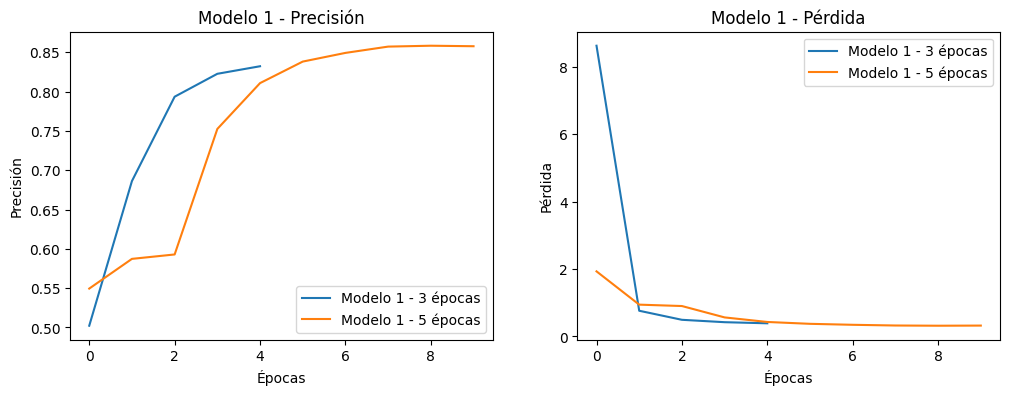

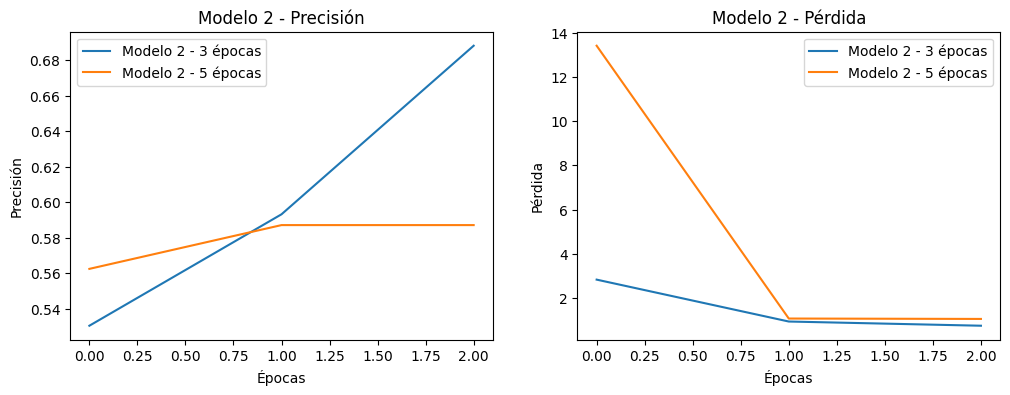

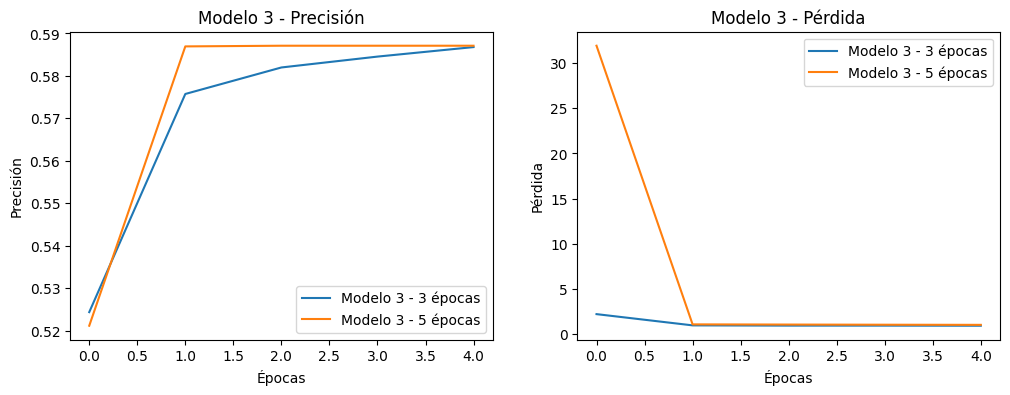

In [ ]:
# Se itera en cada historial
for i in range(1, 4):  # tres modelos
    plt.figure(figsize=(12, 4))

    # Gráfico de precisión
    plt.subplot(1, 2, 1)
    plt.plot(locals()[f'history{i}'].history['accuracy'], label=f'Modelo {i} - 3 épocas')
    plt.plot(locals()[f'history{i+3}'].history['accuracy'], label=f'Modelo {i} - 5 épocas')
    plt.title(f'Modelo {i} - Precisión')
    plt.xlabel('Épocas')
    plt.ylabel('Precisión')
    plt.legend()

    # Gráfico de pérdida
    plt.subplot(1, 2, 2)
    plt.plot(locals()[f'history{i}'].history['loss'], label=f'Modelo {i} - 3 épocas')
    plt.plot(locals()[f'history{i+3}'].history['loss'], label=f'Modelo {i} - 5 épocas')
    plt.title(f'Modelo {i} - Pérdida')
    plt.xlabel('Épocas')
    plt.ylabel('Pérdida')
    plt.legend()

    plt.show()
